# Concrete Crack Detection Classification

### Data Loading and Preprocessing
This section downloads the surface crack detection dataset from KaggleHub, locates positive (cracked) and negative (uncracked) image paths, and then samples 1,000 images from each category to create a balanced and manageable dataset for training. This helps in efficient model development without processing the entire dataset initially.

In [1]:
import os
import glob
import random
import kagglehub

# 1. Download the dataset path via kagglehub (fast & managed)
print("Downloading dataset path...")
dataset_path = kagglehub.dataset_download("arunrk7/surface-crack-detection")

# 2. Locate the positive and negative image paths
pos_dir = os.path.join(dataset_path, "Positive")
neg_dir = os.path.join(dataset_path, "Negative")

# find .jpg files within the directory
# glob returns a list of files that match the pattern
pos = glob.glob(os.path.join(pos_dir, "*.jpg"))
neg = glob.glob(os.path.join(neg_dir, "*.jpg"))

# 3. Only keep 1,000 images of each (2,000 total) to make it highly compact
random.seed(0)

# Safety: if the dataset is larger than 1000 it will returns the minimum value
pos_sample = random.sample(pos, min(1000, len(pos)))
neg_sample = random.sample(neg, min(1000, len(neg)))

files_ = pos_sample + neg_sample
labels = [1] * len(pos_sample) + [0] * len(neg_sample)

print(f"Dataset prepared successfully!")
print(f"Selected: {len(pos_sample)} cracked images, {len(neg_sample)} uncracked images (Total: {len(files_)} images)")

100%|██████████| 233M/233M [00:02<00:00, 111MB/s]

Extracting files...


Dataset prepared successfully!
Selected: 1000 cracked images, 1000 uncracked images (Total: 2000 images)


### Feature Extraction with MobileNetV2
Here, a pre-trained MobileNetV2 model (without the top classification layer) is used as a feature extractor. The `load_img` function preprocesses images by resizing them to 160x160 pixels and applying MobileNetV2's specific input scaling. These processed images are then fed into the MobileNetV2 base model to extract meaningful features, which will be used for classification.

In [2]:
import tensorflow as tf

base = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False, pooling='avg', weights='imagenet')

def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (160,160))
    return tf.keras.applications.mobilenet_v2.preprocess_input(img)

ds = tf.data.Dataset.from_tensor_slices(files_).map(load_img, num_parallel_calls=tf.data.AUTOTUNE).batch(64).prefetch(tf.data.AUTOTUNE)
features = base.predict(ds, verbose=1)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 435ms/step


### Model Training and Evaluation
The extracted features and their corresponding labels are split into training and testing sets. A Logistic Regression classifier is then trained on these features. The model's performance is evaluated using accuracy on the test set, demonstrating how well it can distinguish between cracked and uncracked surfaces based on the MobileNetV2 features.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=0, stratify=labels)
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, clf.predict(X_test)))

Accuracy: 0.9975


### Prediction Function
This helper function, `predict_crack`, takes an image path as input, preprocesses it using the `load_img` function, extracts features with the MobileNetV2 base, and then uses the trained Logistic Regression classifier to predict whether the image contains a crack or not. It prints the prediction for sample positive and negative images.

In [4]:
def predict_crack(path):
    feat = base.predict(load_img(path)[None], verbose=0)
    return "Crack" if clf.predict(feat)[0] == 1 else "No crack"

print(predict_crack(pos[5]), predict_crack(neg[5]))

Crack No crack


### Unified Model Creation and Saving
This section integrates the feature extraction (MobileNetV2 base) and the Logistic Regression classification into a single, unified TensorFlow Keras model. The weights and biases from the trained Logistic Regression model are used to initialize a new `Dense` layer in the Keras model. This unified model is then saved locally in the `.keras` format, making it easy to deploy and use for future predictions.

In [5]:
import tensorflow as tf
import numpy as np

# Extract trained logistic regression coefficients
w = clf.coef_
b = clf.intercept_

# 1. Build unified model pipeline
inputs = tf.keras.Input(shape=(160, 160, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs) # Apply scaling [-1, 1]
features = base(x, training=False)                             # MobileNetV2 base
outputs = tf.keras.layers.Dense(                                # Your Logistic Regression weights
    units=1,
    activation='sigmoid',
    kernel_initializer=tf.keras.initializers.Constant(w.T),
    bias_initializer=tf.keras.initializers.Constant(b)
)(features)

unified_model = tf.keras.Model(inputs, outputs)

# 2. Save model locally
unified_model.save("concrete_crack_model.keras")
print("Unified model saved successfully as 'concrete_crack_model.keras'")

Unified model saved successfully as 'concrete_crack_model.keras'


In [8]:
# download the unified model
from google.colab import files
files.download('concrete_crack_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Gradio User Interface
Finally, a user-friendly web interface is created using Gradio. This interface allows users to upload an image of a concrete surface, which is then passed to the `predict_crack_ui` function. This function loads the unified Keras model, preprocesses the uploaded image, and returns the probability of a crack, presented as clear labels. The `demo.launch(share=True)` command makes the interface publicly accessible.

In [6]:
!pip install -q gradio

In [7]:
import gradio as gr
import tensorflow as tf
import numpy as np

# Load the saved unified model
model = tf.keras.models.load_model("concrete_crack_model.keras")

def predict_crack_ui(image):
    if image is None:
        return "Please upload an image."

    # Preprocess the input image to match training parameters
    img_resized = tf.image.resize(image, (160, 160))
    img_batch = tf.expand_dims(img_resized, 0) # Add batch size dimension (1, 160, 160, 3)

    # Predict (Outputs class probability of a crack)
    probability = float(model.predict(img_batch, verbose=0)[0][0])

    # Formulate output labels and confidence scores
    labels = {
        "Crack Detected ⚠️": probability,
        "No Crack": 1.0 - probability
    }
    return labels

# Create the Gradio interface
demo = gr.Interface(
    fn=predict_crack_ui,
    inputs=gr.Image(label="Upload Concrete Surface Photo", type="numpy"),
    outputs=gr.Label(num_top_classes=1, label="Detection Results"),
    title="🚧 Concrete Crack Detection AI",
    description="Upload an image of a concrete surface to instantly scan for cracks. Powered by MobileNetV2 features and Logistic Regression.",
    theme="soft"
)

# Launch the app
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d96dd93b065e9da666.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 1 - True Positive

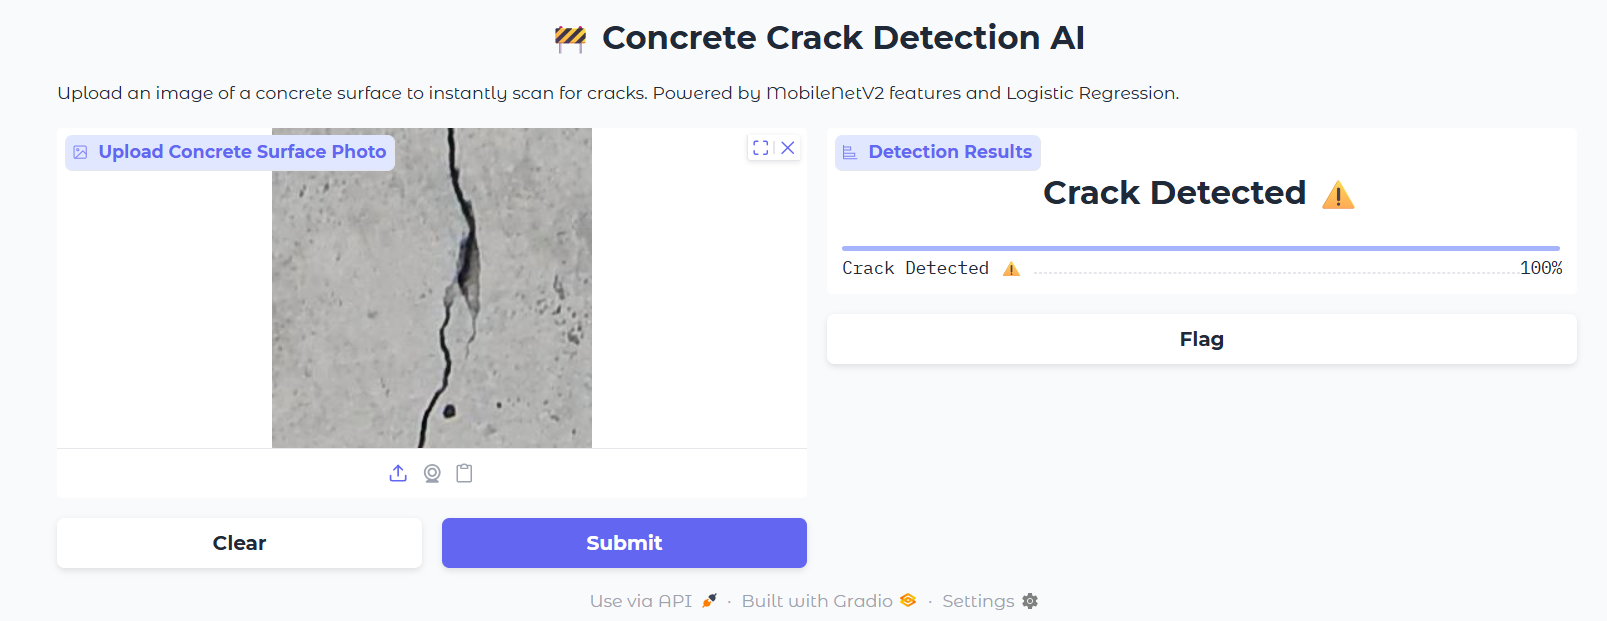

# 2 - False Negative

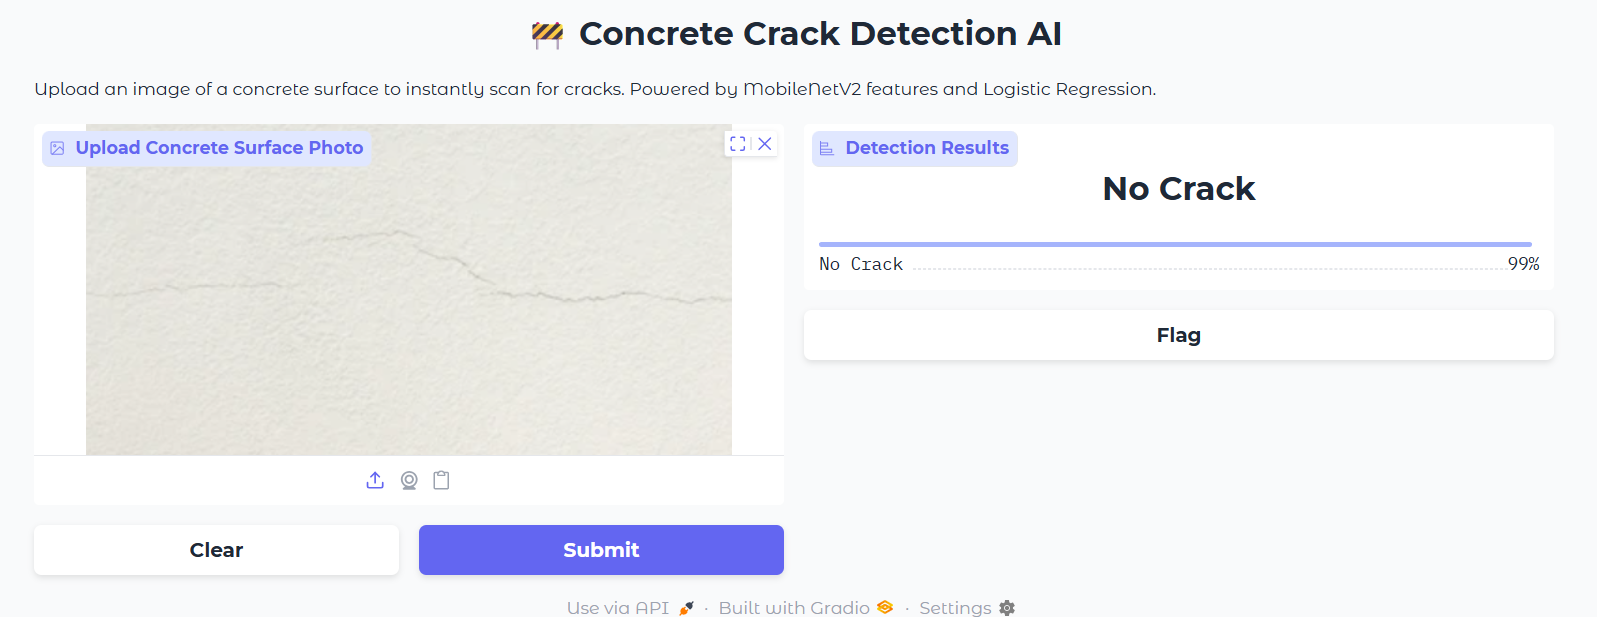

# 3

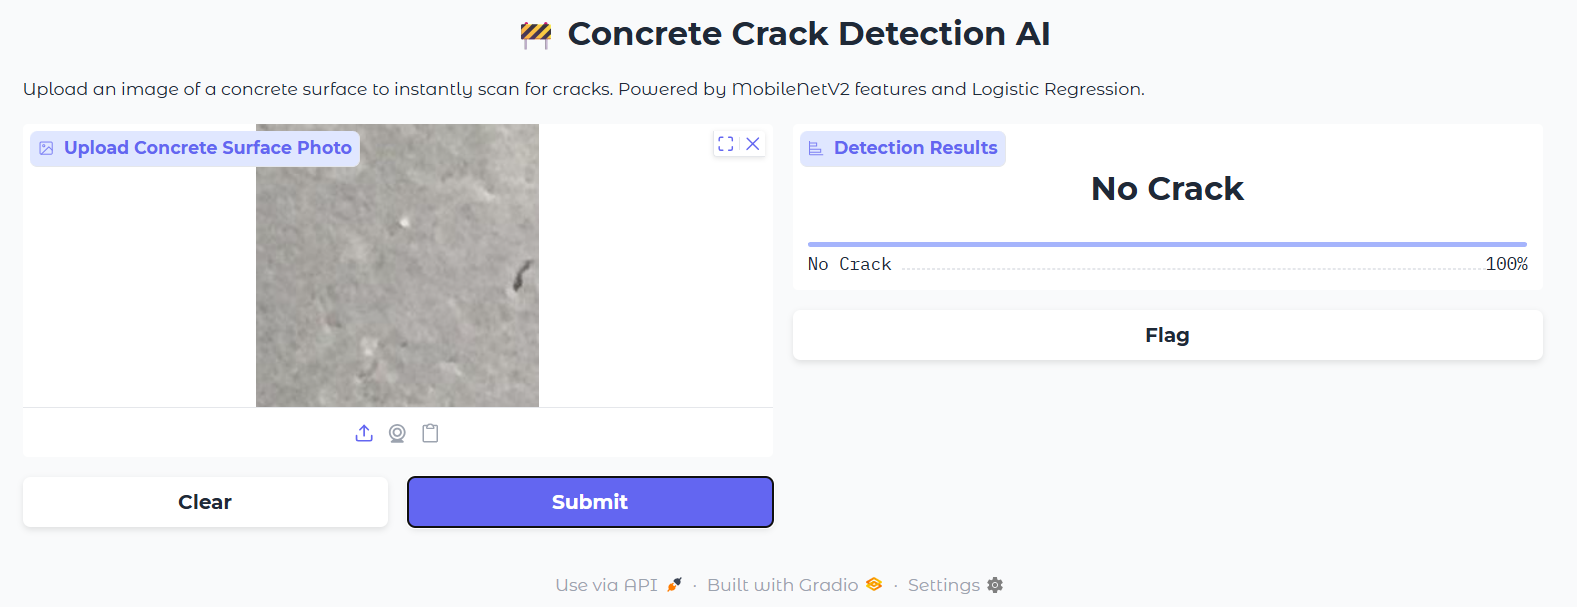